<a href="https://colab.research.google.com/github/dechl-98/dataminingDavidChavez25-3453-2021/blob/main/ActividadU4Selectiva2/CasoPr%C3%A1cticoU4_Selectiva2_DesarrolloSoftware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Tarea Caso Práctico Software2
#Importando las librerías que se necesitarán para trabajar y presentar los datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
#Extraemos desde el github el dataset para trabajar

In [6]:
#Actividad 1. Preparación e inspección inicial del dataset

In [2]:
#creamos variables para mandar a traer el dataset
url = "https://raw.githubusercontent.com/dechl-98/dataminingDavidChavez25-3453-2021/refs/heads/main/ActividadU4Selectiva2/Prestige_modificado.csv"
df = pd.read_csv(url, sep=';') #agregamos una separación por ; para poder manejar los encabezados de las tablas
df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [3]:
#verificamos la información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB


In [4]:
# verificamos valores nulos por columna y los registros que podrían ser duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())

# Registros duplicados
print("\nCantidad de registros duplicados:", df.duplicated().sum())

Valores nulos por columna:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

Cantidad de registros duplicados: 0


In [5]:
# Generamos la estadística descriptitva de las diferentes variables numericas
df.describe()

,education,income,women,prestige,census,type_num
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,10.738039,6797.901961,28.979020,46.833333,5401.774510,1.843137
std,2.728444,4245.922227,31.724931,17.204486,2644.993215,0.817447
min,6.380000,611.000000,0.000000,14.800000,1113.000000,0.000000
25%,8.445000,4106.000000,3.592500,35.225000,3120.500000,1.000000
50%,10.540000,5930.500000,13.600000,43.600000,5135.000000,2.000000
75%,12.647500,8187.250000,52.202500,59.275000,8312.500000,2.000000
max,15.970000,25879.000000,97.510000,87.200000,9517.000000,3.000000


La variable income tiene alta dispersión (std ≈ 4,245), lo que puede influir en los modelos de agrupación

In [8]:
#Actividad 2. Análisis de relación entre variables

In [7]:
#Calculamos la matriz de correlación de las variables numéricas.
# Selección de variables numéricas
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
# Matriz de correlación completa
matriz_correlacion = variables_numericas.corr()
print("Matriz de correlación completa (redondeada a 3 decimales):")
display(matriz_correlacion.round(3))
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))

Matriz de correlación completa (redondeada a 3 decimales):


,education,income,women,prestige,census,type_num
education,1.000,0.578,0.062,0.850,-0.823,-0.382
income,0.578,1.000,-0.441,0.715,-0.361,-0.368
women,0.062,-0.441,1.000,-0.118,-0.227,0.251
prestige,0.850,0.715,-0.118,1.000,-0.635,-0.465
census,-0.823,-0.361,-0.227,-0.635,1.000,0.288
type_num,-0.382,-0.368,0.251,-0.465,0.288,1.000


prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


Las variables con relación positiva más fuerte respecto a Prestige son Education (r ≈ 0.85) e Income (r ≈ 0.71)

In [11]:
#Actividad 3. Visualización de resultados

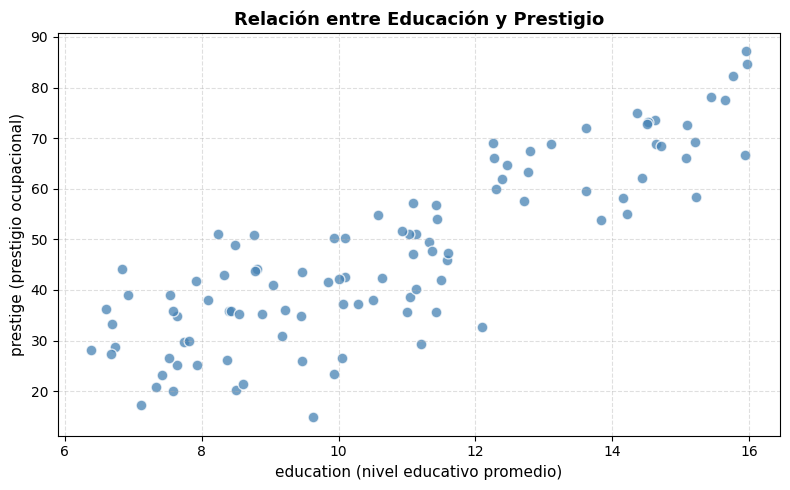

In [8]:
#Gráfica de dispersión entre prestige y education.
plt.figure(figsize=(8, 5))
plt.scatter(df['education'], df['prestige'], color='steelblue', alpha=0.75, edgecolors='white', s=60)
plt.xlabel('education (nivel educativo promedio)', fontsize=11)
plt.ylabel('prestige (prestigio ocupacional)', fontsize=11)
plt.title('Relación entre Educación y Prestigio', fontsize=13, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

A medida que aumenta el promedio de años de educación asociados a una ocupación, su valoración social también tiende a ser mayor.

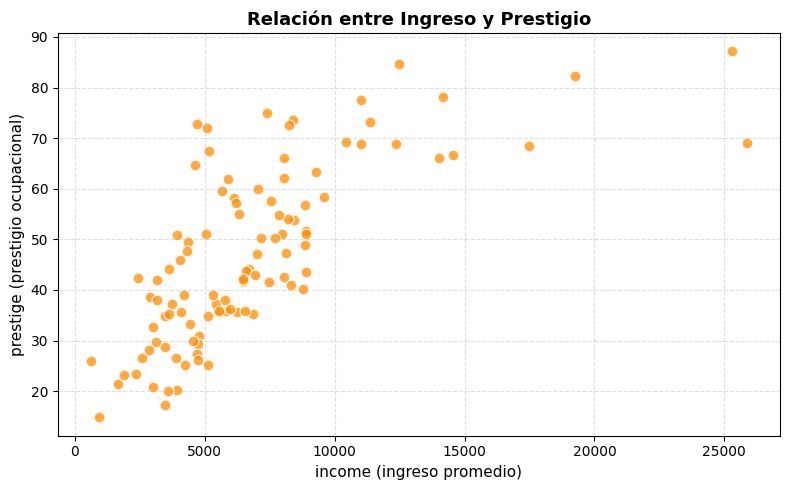

In [9]:
#Gráfica de dispersión entre Prestige e Income
plt.figure(figsize=(8, 5))
plt.scatter(df['income'], df['prestige'], color='darkorange', alpha=0.75, edgecolors='white', s=60)
plt.xlabel('income (ingreso promedio)', fontsize=11)
plt.ylabel('prestige (prestigio ocupacional)', fontsize=11)
plt.title('Relación entre Ingreso y Prestigio', fontsize=13, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

La relación entre ingreso y prestigio es positiva pero con mayor dispersión que la de educación. Existen ocupaciones con ingresos altos y prestigio moderado (como algunos oficios técnicos bien remunerados), y otras con ingresos bajos pero mayor reconocimiento social.

/tmp/ipykernel_2095/1256338522.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden, fontsize=9)


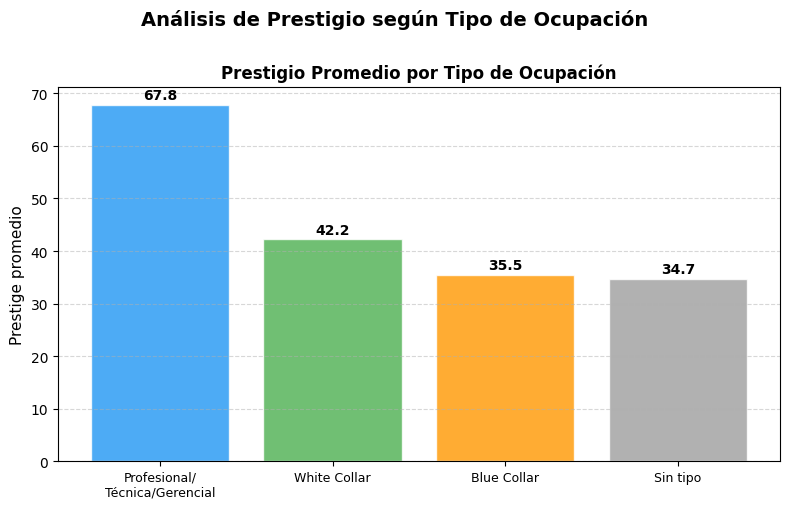

Prestigio promedio por tipo de ocupación:


,mean,median,std,count
Type_label,,,,
Blue Collar,35.53,35.9,10.02,44
Profesional/\nTécnica/Gerencial,67.85,68.4,8.68,31
Sin tipo,34.72,35.0,17.68,4
White Collar,42.24,41.5,9.52,23


In [11]:
# Gráfica comparativa del prestigio por tipo de ocupación
type_labels = {0: 'Sin tipo', 1: 'Profesional/\nTécnica/Gerencial', 2: 'Blue Collar', 3: 'White Collar'}
df['Type_label'] = df['type_num'].map(type_labels)

orden = ['Profesional/\nTécnica/Gerencial', 'White Collar', 'Blue Collar', 'Sin tipo']
colors_box = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E']
fig, ax = plt.subplots(figsize=(8, 5))


# Barras con promedio
promedios = df.groupby('Type_label')['prestige'].mean().reindex(orden)
bars = ax.bar(orden, promedios.values, color=colors_box, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, promedios.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Prestige promedio', fontsize=11)
ax.set_title('Prestigio Promedio por Tipo de Ocupación', fontsize=12, fontweight='bold')
ax.set_xticklabels(orden, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Análisis de Prestigio según Tipo de Ocupación', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Prestigio promedio por tipo de ocupación:")
display(df.groupby('Type_label')['prestige'].agg(['mean', 'median', 'std', 'count']).round(2))

 Las ocupaciones de tipo Profesional/Técnica/Gerencial concentran los niveles más altos de prestigio, tanto en promedio como en mediana. Los roles que combinan mayor formación, responsabilidad y especialización técnica o gerencial suelen recibir mayor valoración social.

In [12]:
#Actividad 4. Análisis de agrupación de ocupaciones (K-Means)
# Selección de variables para clusterización
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

# Escalamiento de datos — obligatorio antes de K-Means
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)
print("Variables seleccionadas para clusterización:", columnas_cluster)
print("Datos escalados (primeras 5 filas):")
print(pd.DataFrame(X_escalado, columns=columnas_cluster).head().round(3))

Variables seleccionadas para clusterización: ['education', 'income', 'women', 'prestige', 'type_num']
Datos escalados (primeras 5 filas):
   education  income  women  prestige  type_num
0      0.874   1.314 -0.564     1.283    -1.037
1      0.561   4.516 -0.791     1.301    -1.037
2      0.748   0.585 -0.421     0.968    -1.037
3      0.251   0.489 -0.629     0.582    -1.037
4      1.430   0.380 -0.548     1.558    -1.037


In [13]:
# K-Means con cuatro clústers
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

print("=== Centroides del modelo K=4 (valores originales promedio) ===")
centroides_k4 = df.groupby('Cluster_4')[columnas_cluster].mean().round(2)
centroides_k4['n_ocupaciones'] = df.groupby('Cluster_4').size()
display(centroides_k4)

=== Centroides del modelo K=4 (valores originales promedio) ===


,education,income,women,prestige,type_num,n_ocupaciones
Cluster_4,,,,,,
0,13.59,7329.35,36.35,63.33,0.95,20
1,8.82,5878.74,9.60,37.26,2.09,47
2,10.12,3545.04,74.16,37.76,2.57,23
3,14.69,15746.83,6.00,74.23,1.00,12


El clúster con mayor prestigio promedio agrupa ocupaciones profesionales con alta educación e ingresos. El clúster de menor prestigio concentra ocupaciones manuales o de servicios básicos. Los clústeres intermedios representan perfiles técnicos y administrativos.

In [14]:
# K-Means con cinco clúster
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print("=== Centroides del modelo K=5 (valores originales promedio) ===")
centroides_k5 = df.groupby('Cluster_5')[columnas_cluster].mean().round(2)
centroides_k5['n_ocupaciones'] = df.groupby('Cluster_5').size()
display(centroides_k5)

=== Centroides del modelo K=5 (valores originales promedio) ===


,education,income,women,prestige,type_num,n_ocupaciones
Cluster_5,,,,,,
0,10.94,3909.12,73.76,41.50,2.88,17
1,9.31,6922.03,5.84,42.18,2.25,32
2,13.59,7329.35,36.35,63.33,0.95,20
3,7.78,3327.48,34.10,26.87,1.71,21
4,14.69,15746.83,6.00,74.23,1.00,12


El modelo subdivide uno de los clústeres intermedios de K=4, separando ocupaciones técnicas de ocupaciones administrativas con características distintas.

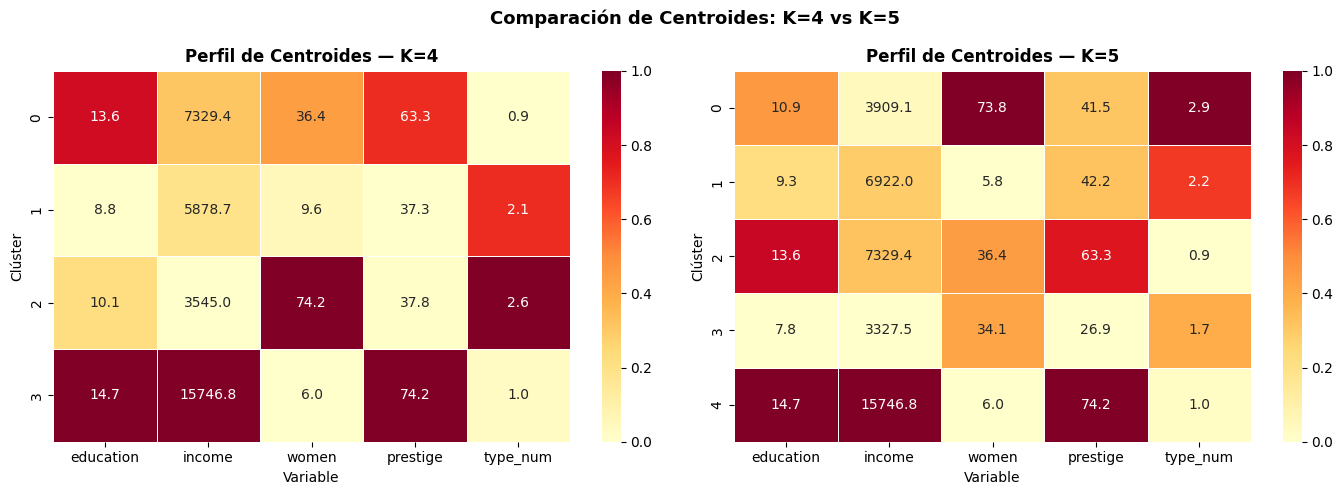

In [15]:
# Comparación visual de los centroides
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap k=4
sns.heatmap(
    centroides_k4[columnas_cluster].apply(lambda x: (x - x.min()) / (x.max() - x.min())),
    annot=centroides_k4[columnas_cluster].values,
    fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=axes[0], annot_kws={"size": 10}
)
axes[0].set_title("Perfil de Centroides — K=4", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Variable")
axes[0].set_ylabel("Clúster")

# Heatmap k=5
sns.heatmap(
    centroides_k5[columnas_cluster].apply(lambda x: (x - x.min()) / (x.max() - x.min())),
    annot=centroides_k5[columnas_cluster].values,
    fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=axes[1], annot_kws={"size": 10}
)
axes[1].set_title("Perfil de Centroides — K=5", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Variable")
axes[1].set_ylabel("Clúster")

plt.suptitle("Comparación de Centroides: K=4 vs K=5", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
#Clúster cuatro y clúster cinco
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
